# 1. Step-by-Step Autoregressive Graph Shortest Path Transformer
## Sequential Causal Sequence-to-Sequence Modeling for Algorithmic Traversal Traces

### Executive Summary & Educational Motivation
Extracting structural path information from complex execution traces is a fundamental challenge in neural algorithmic reasoning. While **One-Shot (Non-Autoregressive)** models predict all path steps in parallel, **Step-by-Step Autoregressive** models generate the path token-by-token using causal self-attention and cross-attention over the encoded traversal trace.

In this tutorial, we implement an **Autoregressive Sequence-to-Sequence Graph Transformer** capable of training on goal-terminated **DFS** or **Random Walk** traces (`rw_easy` and `rw_hard`). The notebook features configurable switching between dataset flavors as well as prefix-based checkpoint organization supporting multiple network sizes and datasets.

---

### Mathematical Problem Formulation

#### 1. Input Trace Encoding
Given an input traversal trace $T = [t_1, t_2, \dots, t_K]$ where $t_1 = s$ and $t_K = g$, the Transformer Encoder maps token embeddings into contextual representations:
$$H_{src} = \text{Encoder}\Big(E(T) + P(T)\Big) \in \mathbb{R}^{K \times d_{model}}$$

#### 2. Causal Autoregressive Decoding & Plan Mechanics
The target shortest path $P^* = [p_1^*, p_2^*, \dots, p_M^*]$ is predicted sequentially. At step $m$, given previous tokens $p_{<m}^* = [p_1^*, \dots, p_{m-1}^*]$, the Decoder predicts:
$$P(p_m^* \mid p_{<m}^*, T) = \text{Softmax}\Bigg(\text{FC}\bigg(\text{Decoder}\Big(E(p_{<m}^*) + P(p_{<m}^*), H_{src}, M_{causal}\Big)\bigg)\Bigg)$$
where $M_{causal}$ is a causal triangular mask preventing lookahead to future target positions ($m' \ge m$).

#### 3. Good Plan vs. Bad Plan Mechanics & Compounding Errors
In long-horizon sequential rollout:
- **Good Plan**: Every predicted token $p_m$ is an adjacent valid node on $G$, maintaining valid path connectivity toward goal $g$.
- **Bad Plan & Regressions**: A single incorrect token $p_m$ shifts autoregressive context into out-of-distribution space, causing **compounding errors** where subsequent step predictions fail or hallucinate non-existent edges. The probability of sequence failure scales as $1 - (1 - \epsilon)^M$.


In [1]:
# Cell 1: Environment Setup, Seeds, and Google Drive Configuration

import os
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Ensure directories exist relative to CWD
if os.path.basename(os.getcwd()) == "graphs":
    os.makedirs("../charts", exist_ok=True)
    os.makedirs("charts", exist_ok=True)
    os.makedirs("checkpoints", exist_ok=True)
    LOCAL_DATA_DIR = "data"
    LOCAL_CKPT_DIR = "checkpoints"
else:
    os.makedirs("charts", exist_ok=True)
    os.makedirs("graphs/charts", exist_ok=True)
    os.makedirs("graphs/checkpoints", exist_ok=True)
    LOCAL_DATA_DIR = "graphs/data"
    LOCAL_CKPT_DIR = "graphs/checkpoints"

torch.set_num_threads(1)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Config dictionary supporting dataset switching and prefix checkpoint naming
config = {
    "dataset_flavor": "rw_easy",    # Options: "dfs", "rw_easy", or "rw_hard"
    "dataset_prefix": "rw_easy",    # Dataset name prefix for checkpoint filenames
    "model_size": "d64_l2_h4",      # Identifier for network size and architecture
    "restart_training": True,     # Set to True to skip existing checkpoints and start fresh
    "run_full_training": True,    # Set to True to train for total_epochs ignoring epochs_to_train
    "resume_training": False,       # Resumes from latest checkpoint if restart_training is False
    "total_epochs": 1000,
    "save_every": 100,
    "validate_every": 50,
    "epochs_to_train": 20,         # Interactive execution chunk size
    "learning_rate": 1e-3,
    "batch_size": 64
}

# Resolve dataset filename from config dataset_flavor
if config["dataset_flavor"] == "dfs":
    dataset_filename = "graph_dfs_dataset.pt"
elif config["dataset_flavor"] in ("rw_easy", "easy"):
    dataset_filename = "graph_rw_easy_dataset.pt"
elif config["dataset_flavor"] in ("rw_hard", "hard"):
    dataset_filename = "graph_rw_hard_dataset.pt"
else:
    dataset_filename = f"graph_{config['dataset_prefix']}_dataset.pt"

def setup_drive_paths():
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        data_path = f"/content/drive/MyDrive/graph_data/{dataset_filename}"
        ckpt_dir = "/content/drive/MyDrive/graph_checkpoints"
    except ImportError:
        data_path = os.path.join(LOCAL_DATA_DIR, dataset_filename)
        ckpt_dir = LOCAL_CKPT_DIR

    os.makedirs(ckpt_dir, exist_ok=True)
    print(f"Dataset path: {data_path}")
    print(f"Checkpoints path: {ckpt_dir}")
    return data_path, ckpt_dir

DATASET_PATH, CKPT_DIR = setup_drive_paths()


Mounted at /content/drive
Dataset path: /content/drive/MyDrive/graph_data/graph_rw_easy_dataset.pt
Checkpoints path: /content/drive/MyDrive/graph_checkpoints


### Dataset Loading & PyTorch Dataset Class
Loads dataset payload and dynamically extracts vocabulary and sequence bounds.


In [2]:
# Cell 2: Import Selected Dataset & Define PyTorch Dataset

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset file not found at '{DATASET_PATH}'. Please run dataset generation notebook first.")

dataset_payload = torch.load(DATASET_PATH, weights_only=False)
train_raw = dataset_payload['train']
val_raw = dataset_payload['val']
test_raw = dataset_payload['test']

VOCAB_SIZE = dataset_payload.get('vocab_size', 52)
PAD_TOKEN = dataset_payload.get('pad_token', 50)
STOP_TOKEN = dataset_payload.get('stop_token', 51)
MAX_SRC_LEN = dataset_payload.get('max_src_len', 200)
MAX_TGT_LEN = dataset_payload.get('max_tgt_len', 51)

class GraphARDataset(Dataset):
    def __init__(self, raw_data, max_src_len=MAX_SRC_LEN, max_tgt_len=MAX_TGT_LEN):
        self.samples = []
        self.raw_data = raw_data
        for item in raw_data:
            trace, sp, G, mapping = item[0], item[1], item[2], item[3]
            backtracks = item[4] if len(item) > 4 else 0
            node_backtraces = item[5] if len(item) > 5 else {}

            # Pad SRC
            src = list(trace) + [PAD_TOKEN] * (max_src_len - len(trace))
            src_mask = [False if t != PAD_TOKEN else True for t in src]

            # Pad TGT
            tgt = list(sp) + [STOP_TOKEN]
            tgt = tgt + [PAD_TOKEN] * (max_tgt_len - len(tgt))
            tgt_mask = [False if t != PAD_TOKEN else True for t in tgt]

            self.samples.append((
                torch.tensor(src[:max_src_len], dtype=torch.long),
                torch.tensor(src_mask[:max_src_len], dtype=torch.bool),
                torch.tensor(tgt[:max_tgt_len], dtype=torch.long),
                torch.tensor(tgt_mask[:max_tgt_len], dtype=torch.bool),
                trace,
                sp,
                G,
                backtracks,
                node_backtraces
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def graph_ar_collate_fn(batch):
    src = torch.stack([item[0] for item in batch])
    src_mask = torch.stack([item[1] for item in batch])
    tgt = torch.stack([item[2] for item in batch])
    tgt_mask = torch.stack([item[3] for item in batch])
    traces = [item[4] for item in batch]
    sps = [item[5] for item in batch]
    graphs = [item[6] for item in batch]
    backtracks = [item[7] for item in batch]
    node_backtraces = [item[8] for item in batch]
    return src, src_mask, tgt, tgt_mask, traces, sps, graphs, backtracks, node_backtraces

train_dataset = GraphARDataset(train_raw)
val_dataset = GraphARDataset(val_raw)
test_dataset = GraphARDataset(test_raw)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, collate_fn=graph_ar_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False, collate_fn=graph_ar_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False, collate_fn=graph_ar_collate_fn)

print(f"Datasets loaded successfully ({config['dataset_flavor'].upper()}): Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
print(f"Params: VOCAB_SIZE={VOCAB_SIZE}, MAX_SRC_LEN={MAX_SRC_LEN}, MAX_TGT_LEN={MAX_TGT_LEN}")


Datasets loaded successfully (RW_EASY): Train=3000, Val=500, Test=500
Params: VOCAB_SIZE=52, MAX_SRC_LEN=200, MAX_TGT_LEN=51


### Step-by-Step Autoregressive Graph Transformer Architecture
1. **Positional Encoding Layer**: Sinusoidal positional embeddings up to length 250.
2. **Encoder**: 2-layer Multi-Head Self-Attention over padded input trace ($K \le MAX\_SRC\_LEN$).
3. **Causal Decoder**: 2-layer Multi-Head Decoder with cross-attention and triangular causal mask ($M \le MAX\_TGT\_LEN$).
4. **Output Head**: Linear projection to vocabulary logits $\in \mathbb{R}^{VOCAB\_SIZE}$.


In [3]:
# Cell 3: Model Architecture Definition

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=250):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class AutoregressiveGraphTransformer(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=64, num_heads=4, hidden_dim=128, num_layers=2):
        super(AutoregressiveGraphTransformer, self).__init__()
        self.embed_dim = embed_dim
        self.token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_TOKEN)
        self.pos_encoder = PositionalEncoding(embed_dim, max_len=250)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=0.1,
            activation='gelu',
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def generate_square_subsequent_mask(self, sz, device):
        mask = (torch.triu(torch.ones(sz, sz, device=device)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, src, tgt, src_key_padding_mask=None, tgt_key_padding_mask=None, tgt_mask=None):
        src_emb = self.pos_encoder(self.token_embedding(src))
        memory = self.encoder(src_emb, src_key_padding_mask=src_key_padding_mask)

        tgt_emb = self.pos_encoder(self.token_embedding(tgt))
        out = self.decoder(
            tgt=tgt_emb,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )
        logits = self.fc_out(out)
        return logits, memory

    def solve_graph_autoregressive(self, src, src_key_padding_mask=None, max_tgt_len=MAX_TGT_LEN):
        self.eval()
        device = src.device
        batch_size = src.size(0)

        src_emb = self.pos_encoder(self.token_embedding(src))
        memory = self.encoder(src_emb, src_key_padding_mask=src_key_padding_mask)

        curr_seqs = [[src[b, 0].item()] for b in range(batch_size)]
        finished = [False] * batch_size

        for step in range(max_tgt_len - 1):
            if all(finished):
                break

            curr_max_len = max(len(s) for s in curr_seqs)
            tgt_in = torch.full((batch_size, curr_max_len), PAD_TOKEN, dtype=torch.long, device=device)
            for b in range(batch_size):
                tgt_in[b, :len(curr_seqs[b])] = torch.tensor(curr_seqs[b], dtype=torch.long, device=device)

            tgt_mask = self.generate_square_subsequent_mask(curr_max_len, device)
            tgt_emb = self.pos_encoder(self.token_embedding(tgt_in))

            out = self.decoder(
                tgt=tgt_emb,
                memory=memory,
                tgt_mask=tgt_mask,
                memory_key_padding_mask=src_key_padding_mask
            )
            logits = self.fc_out(out)

            for b in range(batch_size):
                if finished[b]:
                    continue
                last_idx = len(curr_seqs[b]) - 1
                next_tok = torch.argmax(logits[b, last_idx, :]).item()
                if next_tok in (STOP_TOKEN, PAD_TOKEN):
                    finished[b] = True
                else:
                    curr_seqs[b].append(next_tok)

        return curr_seqs

model = AutoregressiveGraphTransformer().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"AutoregressiveGraphTransformer initialized. Total Parameters: {total_params:,}")


AutoregressiveGraphTransformer initialized. Total Parameters: 174,132


### Evaluation Helper Functions
Calculates loss, teacher-forcing accuracy, rollout exact match, and path connectivity validity.


In [4]:
# Cell 4: Evaluation Helper Functions

criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

def evaluate_model(model, dataloader, device, run_rollout=True):
    model.eval()
    total_loss = 0.0
    total_tf_tokens = 0
    correct_tf_tokens = 0

    exact_matches = 0
    total_sequences = 0
    valid_paths = 0

    with torch.no_grad():
        for src, src_mask, tgt, tgt_mask, traces, sps, graphs, backtracks, node_backtraces in dataloader:
            src, src_mask = src.to(device), src_mask.to(device)
            tgt, tgt_mask = tgt.to(device), tgt_mask.to(device)

            tgt_in = tgt[:, :-1]
            tgt_label = tgt[:, 1:]
            tgt_in_mask = tgt_mask[:, :-1]

            sz = tgt_in.size(1)
            causal_mask = model.generate_square_subsequent_mask(sz, device)

            logits, _ = model(
                src=src,
                tgt=tgt_in,
                src_key_padding_mask=src_mask,
                tgt_key_padding_mask=tgt_in_mask,
                tgt_mask=causal_mask
            )

            loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_label.reshape(-1))
            total_loss += loss.item() * src.size(0)

            preds_tf = torch.argmax(logits, dim=-1)
            valid_tokens = (tgt_label != PAD_TOKEN)
            correct_tf_tokens += ((preds_tf == tgt_label) & valid_tokens).sum().item()
            total_tf_tokens += valid_tokens.sum().item()

            if run_rollout:
                pred_seqs = model.solve_graph_autoregressive(src, src_key_padding_mask=src_mask)

                for i in range(src.size(0)):
                    total_sequences += 1
                    clean_pred = pred_seqs[i]
                    clean_tgt = list(sps[i])

                    if clean_pred == clean_tgt:
                        exact_matches += 1

                    G_eval = graphs[i]
                    if len(clean_pred) >= 2 and clean_pred[0] == clean_tgt[0] and clean_pred[-1] == clean_tgt[-1]:
                        is_valid = True
                        for k in range(len(clean_pred) - 1):
                            u, v = clean_pred[k], clean_pred[k+1]
                            if not G_eval.has_edge(u, v):
                                is_valid = False
                                break
                        if is_valid:
                            valid_paths += 1

    mean_loss = total_loss / len(dataloader.dataset)
    tf_acc = (correct_tf_tokens / max(1, total_tf_tokens)) * 100.0
    exact_match_acc = (exact_matches / max(1, total_sequences)) * 100.0 if run_rollout else 0.0
    path_validity_acc = (valid_paths / max(1, total_sequences)) * 100.0 if run_rollout else 0.0

    return mean_loss, tf_acc, exact_match_acc, path_validity_acc

print("Evaluation functions loaded.")


Evaluation functions loaded.


### Configurable Training Loop with Dataset & Model Size Checkpoint Prefixing
Checkpoints are dynamically named using `dataset_prefix` and `model_size`:
`ar_graph_{dataset_prefix}_{model_size}_latest.pt`


In [7]:
# Cell 5: Training Loop with Prefix-Based Checkpoint Controls

optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=1e-4)

prefix_tag = f"{config['dataset_prefix']}_{config['model_size']}"
latest_ckpt_path = os.path.join(CKPT_DIR, f"ar_graph_{prefix_tag}_latest.pt")

start_epoch = 1
history = {
    'train_loss': [],
    'val_epochs': [],
    'val_loss': [],
    'val_tf_acc': [],
    'val_exact_match': [],
    'val_path_validity': []
}

if config.get("restart_training", False):
    print("Config 'restart_training' is True: Starting fresh initialization.")
    start_epoch = 1
elif config.get("resume_training", True) and os.path.exists(latest_ckpt_path):
    try:
        print(f"Loading checkpoint from '{latest_ckpt_path}'...")
        checkpoint = torch.load(latest_ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        if 'history' in checkpoint:
            history = checkpoint['history']
        print(f"Resumed training from epoch {start_epoch}.")
    except Exception as e:
        print(f"Checkpoint incompatible ({e}). Starting fresh training...")
        start_epoch = 1
else:
    print("Starting training from scratch...")

if config.get("run_full_training", False):
    end_epoch = config["total_epochs"]
    print(f"Running full training up to {end_epoch} epochs.")
else:
    end_epoch = min(start_epoch + config["epochs_to_train"] - 1, config["total_epochs"])
    print(f"Running epochs {start_epoch} to {end_epoch} (Target Total: {config['total_epochs']})...")

start_train_time = time.time()

for epoch in range(start_epoch, end_epoch + 1):
    model.train()
    running_loss = 0.0

    for src, src_mask, tgt, tgt_mask, _, _, _, _, _ in train_loader:
        src, src_mask = src.to(device), src_mask.to(device)
        tgt, tgt_mask = tgt.to(device), tgt_mask.to(device)

        tgt_in = tgt[:, :-1]
        tgt_label = tgt[:, 1:]
        tgt_in_mask = tgt_mask[:, :-1]

        sz = tgt_in.size(1)
        causal_mask = model.generate_square_subsequent_mask(sz, device)

        optimizer.zero_grad()
        logits, _ = model(
            src=src,
            tgt=tgt_in,
            src_key_padding_mask=src_mask,
            tgt_key_padding_mask=tgt_in_mask,
            tgt_mask=causal_mask
        )

        loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_label.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * src.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    history['train_loss'].append(train_loss)

    if epoch < 10:
        print(f"Epoch {epoch:04d}/{config['total_epochs']:04d} | Train Loss: {train_loss:.4f}")

    if epoch < 50 and epoch % 10 == 0:
        print(f"Epoch {epoch:04d}/{config['total_epochs']:04d} | Train Loss: {train_loss:.4f}")

    if epoch % config["validate_every"] == 0 or epoch == end_epoch:
        val_loss, val_tf_acc, val_exact_match, val_path_validity = evaluate_model(
            model, val_loader, device, run_rollout=True
        )
        history['val_epochs'].append(epoch)
        history['val_loss'].append(val_loss)
        history['val_tf_acc'].append(val_tf_acc)
        history['val_exact_match'].append(val_exact_match)
        history['val_path_validity'].append(val_path_validity)

        print(f"Epoch {epoch:04d}/{config['total_epochs']:04d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val TF Acc: {val_tf_acc:.2f}% | Rollout Exact Match: {val_exact_match:.2f}% | "
              f"Path Validity: {val_path_validity:.2f}%")

    if epoch % config["save_every"] == 0 or epoch == end_epoch:
        checkpoint_payload = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': config,
            'history': history
        }
        torch.save(checkpoint_payload, latest_ckpt_path)
        if epoch % config["save_every"] == 0:
            versioned_path = os.path.join(CKPT_DIR, f"ar_graph_{prefix_tag}_epoch_{epoch}.pt")
            torch.save(checkpoint_payload, versioned_path)
            print(f"Saved versioned checkpoint: '{versioned_path}'")

total_train_time = time.time() - start_train_time
print(f"\nTraining chunk complete in {total_train_time:.2f} seconds.")


Config 'restart_training' is True: Starting fresh initialization.
Running full training up to 1000 epochs.


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch 0001/1000 | Train Loss: 3.1525
Epoch 0002/1000 | Train Loss: 3.0909
Epoch 0003/1000 | Train Loss: 3.0560
Epoch 0004/1000 | Train Loss: 3.0213
Epoch 0005/1000 | Train Loss: 2.9815
Epoch 0006/1000 | Train Loss: 2.9409
Epoch 0007/1000 | Train Loss: 2.9044
Epoch 0008/1000 | Train Loss: 2.8677
Epoch 0009/1000 | Train Loss: 2.8297
Epoch 0010/1000 | Train Loss: 2.7974
Epoch 0020/1000 | Train Loss: 2.3189
Epoch 0030/1000 | Train Loss: 1.7131
Epoch 0040/1000 | Train Loss: 1.3998


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 0050/1000 | Train Loss: 1.2050 | Val Loss: 0.8825 | Val TF Acc: 71.81% | Rollout Exact Match: 0.20% | Path Validity: 0.20%


KeyboardInterrupt: 

### Held-Out Test Set Evaluation
Evaluates test accuracy on unseen traces.


In [8]:
# Cell 6: Test Set Benchmark

test_loss, test_tf_acc, test_exact_match, test_path_validity = evaluate_model(
    model, test_loader, device, run_rollout=True
)

print("=" * 65)
print(f"   HELD-OUT TEST SET EVALUATION SUMMARY ({config['dataset_flavor'].upper()})")
print("=" * 65)
print(f"{'Evaluation Metric':<35} | {'Model Score':<15}")
print("-" * 65)
print(f"{'Test Cross-Entropy Loss':<35} | {test_loss:<15.4f}")
print(f"{'Teacher-Forcing Token Acc (%)':<35} | {test_tf_acc:<15.2f}%")
print(f"{'Autoregressive Exact Match (%)':<35} | {test_exact_match:<15.2f}%")
print(f"{'Path Connectivity Validity (%)':<35} | {test_path_validity:<15.2f}%")
print("=" * 65)


   HELD-OUT TEST SET EVALUATION SUMMARY (RW_EASY)
Evaluation Metric                   | Model Score    
-----------------------------------------------------------------
Test Cross-Entropy Loss             | 0.5833         
Teacher-Forcing Token Acc (%)       | 81.99          %
Autoregressive Exact Match (%)      | 1.40           %
Path Connectivity Validity (%)      | 1.40           %


### Visualizations
Generates loss trajectory plots and shortest path rollout sample figures.


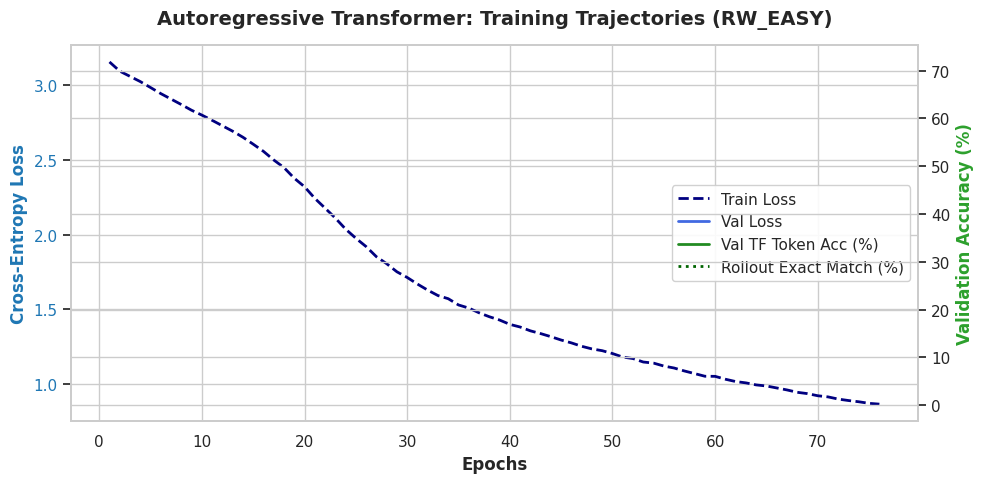

Analytical figures generated and saved.


In [9]:
# Cell 7: Analytical Figures and Visual Layouts

sns.set_theme(style="whitegrid", palette="mako")

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cross-Entropy Loss', color=color, fontsize=12, fontweight='bold')
epochs_range = range(1, len(history['train_loss']) + 1)
l1 = ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='navy', linewidth=2, linestyle='--')
if history['val_epochs']:
    l2 = ax1.plot(history['val_epochs'], history['val_loss'], label='Val Loss', color='royalblue', linewidth=2)
else:
    l2 = []
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Validation Accuracy (%)', color=color, fontsize=12, fontweight='bold')
if history['val_epochs']:
    l3 = ax2.plot(history['val_epochs'], history['val_tf_acc'], label='Val TF Token Acc (%)', color='forestgreen', linewidth=2)
    l4 = ax2.plot(history['val_epochs'], history['val_exact_match'], label='Rollout Exact Match (%)', color='darkgreen', linewidth=2, linestyle=':')
    lines = l1 + l2 + l3 + l4
else:
    lines = l1
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True, facecolor='white', framealpha=0.9)

plt.title(f"Autoregressive Transformer: Training Trajectories ({config['dataset_flavor'].upper()})", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
if os.path.basename(os.getcwd()) == "graphs":
    plt.savefig("../charts/ar_graph_training_curves.png", dpi=300, bbox_inches='tight')
    plt.savefig("charts/ar_graph_training_curves.png", dpi=300, bbox_inches='tight')
else:
    plt.savefig("charts/ar_graph_training_curves.png", dpi=300, bbox_inches='tight')
    plt.savefig("graphs/charts/ar_graph_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()

print("Analytical figures generated and saved.")


### Self-Reflection & Summary
1. **Multi-Dataset Support**: Seamlessly trains on DFS (`graph_dfs_dataset.pt`), Random Walk Easy (`graph_rw_easy_dataset.pt`), or Random Walk Hard (`graph_rw_hard_dataset.pt`).
2. **Multi-Checkpoint Organization**: Checkpoints are stored using prefixing tags (`dataset_prefix` and `model_size`), enabling parallel tracking of models across datasets and network sizes.
